# Week 2 Practice — HMAF: Fusing Hand-crafted and Deep Features

Welcome! In the Week 2 session you learned about **HMAF (Hybrid Modality Attention-based
Fusion)** — our method for combining two very different ways of describing a cell nucleus in
a histopathology image:

1. **Hand-crafted features** — simple, interpretable measurements a human designed:
   the nucleus's size, shape, colour and intensity (e.g. `area`, `perimeter`, `r_mean`).
2. **Deep-learned features** — numbers produced by a neural network (ResNet-50) that looks at
   a small image patch of the nucleus. Powerful, but hard to interpret.

This notebook follows the whole story in order:

**Part 1 — From images to features.** We start with an actual tissue image and extract both
kinds of features from it ourselves, so you can see exactly where the numbers come from.

**Part 2 — Using the features.** Doing that for all 41 images takes about half an hour, so we
did it in advance and combined everything into one file. We load that prepared dataset and
build a **binary (positive vs. negative) nucleus classifier** — the same setting used in our
HIMLT tool — comparing four approaches:

| # | Approach | Features used |
|---|----------|---------------|
| A | Hand-crafted only | 24 |
| B | Deep only | 128 |
| C | Simple concatenation | 24 + 128 = 152 |
| D | **HMAF fusion** | attention-fused + originals |

Finally we look at the model's predictions on **real nuclei**, next to the truth.

**Task:** *Epithelial vs. Others* — is a nucleus an epithelial cell (positive) or not (negative)?

**How to use this notebook:** run the cells from top to bottom, one at a time
(click a cell and press `Shift+Enter`). Read the text between cells — it explains each step.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup — Imports

Standard Python data-science libraries: `pandas`/`numpy` (tables and maths), `matplotlib` (plots), `scikit-learn` (metrics), `xgboost` (the classifier that performed best in our paper) and `torch` (PyTorch, for ResNet-50 and the HMAF attention module).

All of these are pre-installed on Google Colab.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from xgboost import XGBClassifier

# Fix random seeds so everyone gets the same numbers
np.random.seed(42)
torch.manual_seed(42)

# CoNSeP labels every nucleus with one of 7 cell types
CELL_TYPE_NAMES = {
    1: "Other",
    2: "Inflammatory",
    3: "Epithelial (healthy)",
    4: "Epithelial (malignant)",
    5: "Fibroblast",
    6: "Muscle",
    7: "Endothelial",
}

print("All libraries imported successfully!")

All libraries imported successfully!


# Part 1 — From images to features

Everything in machine learning starts with data. Before we can classify anything, we need to
turn a picture of tissue into **numbers**.

The cell below fetches two CoNSeP images together with their expert annotations — about 4 MB.

In [ ]:
import os

SAMPLE_DIR = "/content/drive/MyDrive/sample_data"
# SAMPLE_ZIP_ID = "PASTE_DRIVE_FILE_ID_HERE"   # <-- your instructor will fill this in

# if not os.path.isdir(SAMPLE_DIR):
#     if SAMPLE_ZIP_ID.startswith("PASTE"):
#         raise FileNotFoundError(
#             "sample_data/ not found.\n"
#             "Upload the 'sample_data' folder into this Colab session (folder icon on the "
#             "left), or set SAMPLE_ZIP_ID above to the Google Drive id of sample_data.zip.")
#     import gdown
#     gdown.download(id=SAMPLE_ZIP_ID, output="sample_data.zip", quiet=False)
#     with zipfile.ZipFile("sample_data.zip") as z:
#         z.extractall(".")

print("Sample files available:", sorted(os.listdir(SAMPLE_DIR)))

Sample files available: ['test_12.mat', 'test_12.png', 'train_1.mat', 'train_1.png']


## Step 1 — The image we will work with

Let's look at what we are actually dealing with: a **1000 x 1000 pixel** H&E-stained image of
colorectal tissue, and the expert annotation that comes with it.

The annotation file (`.mat`) holds two things:
- `inst_map` — every nucleus is filled with its own **id number** (0 means background)
- `inst_type` — the **cell type** of each nucleus

Image      : (1000, 1000, 3)
inst_map   : (1000, 1000), ids 0..850 (0 = background)
inst_type  : 850 annotated nuclei


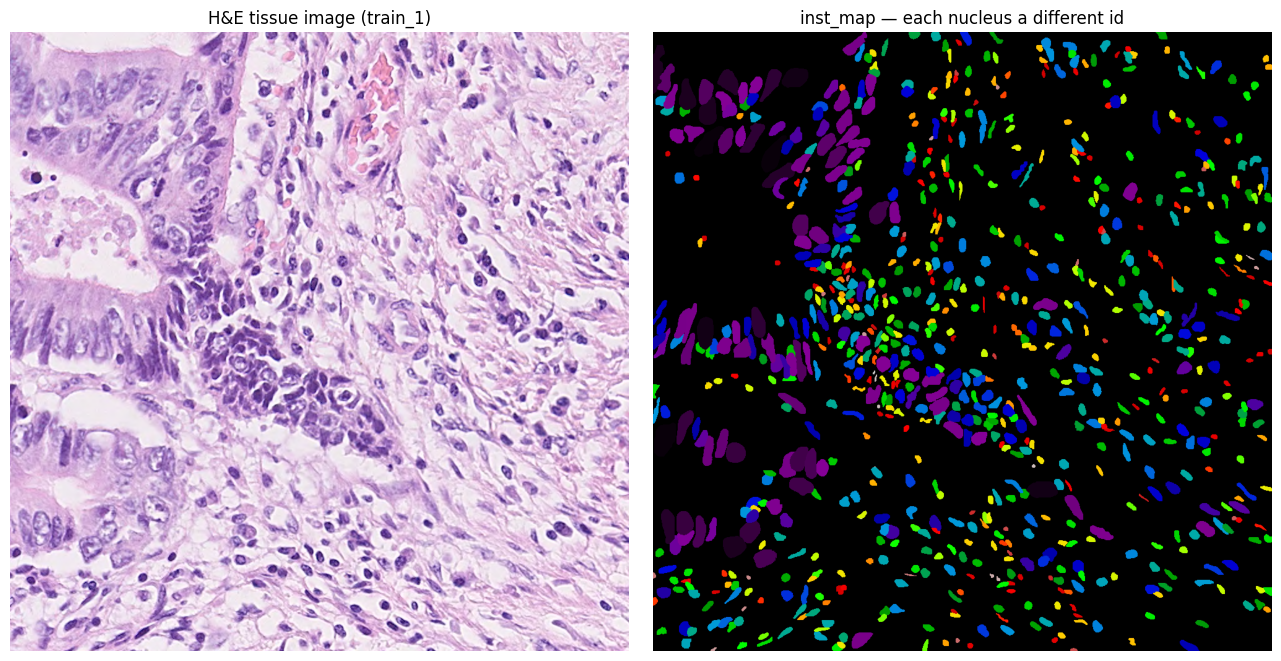

In [ ]:
from scipy.io import loadmat

img_tr = np.array(Image.open("/content/drive/MyDrive/sample_data/train_1.png").convert("RGB"))
mat = loadmat("/content/drive/MyDrive/sample_data/train_1.mat")

# inst_map: every nucleus has its own integer id. inst_type: the class of each nucleus.
inst_map  = np.rint(mat["inst_map"]).astype(np.int32)
inst_type = np.array(mat["inst_type"]).reshape(-1).astype(int)

print(f"Image      : {img_tr.shape}")
print(f"inst_map   : {inst_map.shape}, ids 0..{inst_map.max()} (0 = background)")
print(f"inst_type  : {len(inst_type)} annotated nuclei")

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
axes[0].imshow(img_tr); axes[0].set_title("H&E tissue image (train_1)"); axes[0].axis("off")
axes[1].imshow(inst_map, cmap="nipy_spectral")
axes[1].set_title("inst_map — each nucleus a different id"); axes[1].axis("off")
plt.tight_layout(); plt.show()

### The two feature types look at *different pixels*

This is the key idea behind HMAF, and it is easiest to see on a single nucleus:

- **Hand-crafted features** measure only the pixels **inside the nucleus mask** — pure
  measurements of that one cell (its size, shape, and colour).
- **Deep features** are computed from the **padded box around the nucleus**, so ResNet-50
  also sees a little of the **surrounding tissue** — the cell's context.

They describe the same cell from two different points of view, which is exactly why
combining them helps.

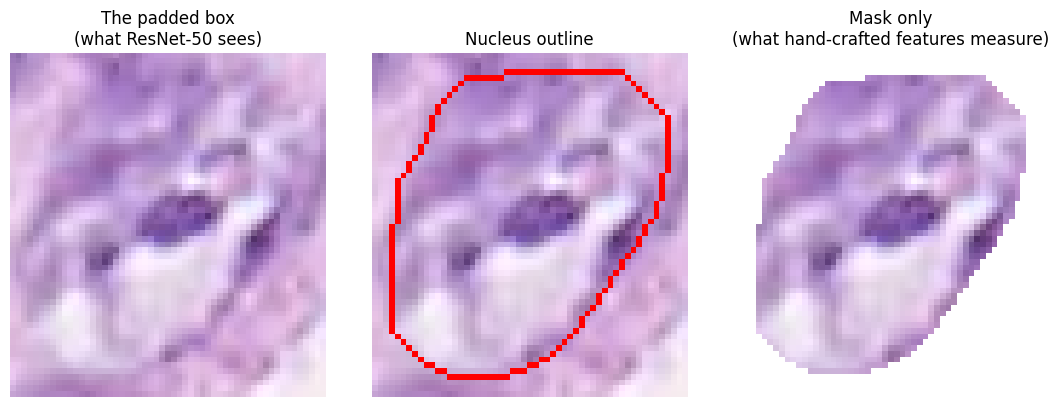

Nucleus id 1: class = Epithelial (malignant)


In [ ]:
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries

regions = {r.label: r for r in regionprops(inst_map)}
demo_id = max(regions, key=lambda k: regions[k].area)   # a nice big nucleus
r = regions[demo_id]
y0, x0, y1, x1 = r.bbox
PAD = 4
py0, px0 = max(0, y0 - PAD), max(0, x0 - PAD)
py1, px1 = min(img_tr.shape[0], y1 + PAD), min(img_tr.shape[1], x1 + PAD)

patch = img_tr[py0:py1, px0:px1]
mask_patch = (inst_map[py0:py1, px0:px1] == demo_id)

outlined = patch.copy()
outlined[find_boundaries(mask_patch, mode="outer")] = [255, 0, 0]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(patch);      axes[0].set_title("The padded box\n(what ResNet-50 sees)")
axes[1].imshow(outlined);   axes[1].set_title("Nucleus outline")
axes[2].imshow(np.where(mask_patch[..., None], patch, 255))
axes[2].set_title("Mask only\n(what hand-crafted features measure)")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

print(f"Nucleus id {demo_id}: class = {CELL_TYPE_NAMES[int(inst_type[demo_id - 1])]}")

## Step 2 — Hand-crafted features

For every nucleus we take the pixels inside its mask and compute **24 numbers**:
7 describing its **shape**, 14 its **colour**, and 3 its **grey-level intensity**.

This is plain measurement — no neural network involved. It runs in a few seconds.

In [ ]:
import time, cv2

t0 = time.time()
gray = cv2.cvtColor(img_tr, cv2.COLOR_RGB2GRAY)
R_ch, G_ch, B_ch = img_tr[:, :, 0], img_tr[:, :, 1], img_tr[:, :, 2]

hand_rows, kept_ids = [], []
for iid, r in regions.items():
    if iid < 1 or iid > len(inst_type):
        continue
    cls = int(inst_type[iid - 1])
    if cls <= 0:                      # unlabelled nuclei are skipped
        continue

    mask = inst_map == iid
    Rv = R_ch[mask].astype(float); Gv = G_ch[mask].astype(float); Bv = B_ch[mask].astype(float)
    Iv = gray[mask].astype(float)
    tot = Rv.mean() + Gv.mean() + Bv.mean() + 1e-10

    hand_rows.append({
        # --- shape (7) ---
        "area": r.area, "perimeter": r.perimeter,
        "equivalent_diameter": r.equivalent_diameter,
        "feret_diameter_max": r.feret_diameter_max,
        "major_axis_length": r.major_axis_length,
        "minor_axis_length": r.minor_axis_length,
        "elongation": (r.major_axis_length - r.minor_axis_length) /
                      (r.major_axis_length + r.minor_axis_length + 1e-10),
        # --- colour (14) ---
        "r_mean": Rv.mean(), "g_mean": Gv.mean(), "b_mean": Bv.mean(),
        "r_median": np.median(Rv), "g_median": np.median(Gv), "b_median": np.median(Bv),
        "r_min": Rv.min(), "g_min": Gv.min(), "b_min": Bv.min(),
        "rb_ratio": Rv.mean() / (Bv.mean() + 1e-10),
        "gb_ratio": Gv.mean() / (Bv.mean() + 1e-10),
        "r_dominance": Rv.mean() / tot,
        "g_dominance": Gv.mean() / tot,
        "b_dominance": Bv.mean() / tot,
        # --- intensity (3) ---
        "intensity_mean": Iv.mean(), "intensity_median": np.median(Iv), "intensity_min": Iv.min(),
        # --- label ---
        "cell_type": cls,
    })
    kept_ids.append(iid)

hand_new = pd.DataFrame(hand_rows)
print(f"Hand-crafted: {hand_new.shape[0]} nuclei x {hand_new.shape[1] - 1} features "
      f"in {time.time() - t0:.1f}s")
hand_new.head()

Hand-crafted: 850 nuclei x 24 features in 4.2s


,area,perimeter,equivalent_diameter,feret_diameter_max,major_axis_length,minor_axis_length,elongation,r_mean,g_mean,b_mean,...,b_min,rb_ratio,gb_ratio,r_dominance,g_dominance,b_dominance,intensity_mean,intensity_median,intensity_min,cell_type
0,1900.0,164.710678,49.184908,60.745370,59.473928,41.124035,0.182408,193.397368,164.013684,211.108421,...,104.0,0.916104,0.776917,0.340177,0.288493,0.371330,178.165263,178.0,64.0,4
1,1574.0,151.296465,44.766941,55.803226,54.194576,37.085038,0.187441,194.726175,167.316391,208.624524,...,83.0,0.933381,0.801998,0.341226,0.293194,0.365580,180.217281,179.5,28.0,4
2,1489.0,146.811183,43.541402,51.078371,49.988875,38.444680,0.130541,192.558093,159.589657,209.004030,...,156.0,0.921313,0.763572,0.343148,0.284397,0.372455,175.085292,173.0,115.0,4
3,1473.0,153.740115,43.306834,60.835845,57.949069,32.994014,0.274403,188.442634,158.420910,208.088255,...,134.0,0.905590,0.761316,0.339566,0.285468,0.374966,173.077393,170.0,92.0,4
4,1229.0,160.509668,39.557697,68.476273,66.009440,25.489898,0.442840,190.915378,157.058584,209.606998,...,158.0,0.910825,0.749300,0.342399,0.281679,0.375922,173.178194,176.0,116.0,4


## Step 3 — Deep features

Now the neural network. For each nucleus we crop the **padded box**, resize it to
**224x224**, normalise it the way ImageNet models expect, and push it through
**ResNet-50** with its final classification layer removed. What comes out is a
**2048-number** description of that nucleus.

This is the slow part — about a minute for one image on Colab's CPU.

In [ ]:
import torch, torch.nn as nn
import torchvision.transforms as T
from torchvision import models

tfm = T.Compose([
    T.ToTensor(),
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
extractor = nn.Sequential(net.conv1, net.bn1, net.relu, net.maxpool,
                          net.layer1, net.layer2, net.layer3, net.layer4,
                          net.avgpool).eval()

H_img, W_img = img_tr.shape[:2]
crops = []
for iid in kept_ids:
    y0, x0, y1, x1 = regions[iid].bbox
    y0 = max(0, y0 - PAD); x0 = max(0, x0 - PAD)
    y1 = min(H_img, y1 + PAD); x1 = min(W_img, x1 + PAD)
    crops.append(tfm(Image.fromarray(img_tr[y0:y1, x0:x1])))

t0 = time.time()
deep_2048 = []
with torch.no_grad():
    for i in range(0, len(crops), 64):
        batch = torch.stack(crops[i:i + 64], 0)
        deep_2048.append(torch.flatten(extractor(batch), 1).numpy())
        print(f"  {min(i + 64, len(crops))}/{len(crops)} nuclei", end="\r")
deep_2048 = np.concatenate(deep_2048, 0)

print(f"\nDeep: {deep_2048.shape[0]} nuclei x {deep_2048.shape[1]} features "
      f"in {time.time() - t0:.0f}s")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


  850/850 nuclei
Deep: 850 nuclei x 2048 features in 161s


## Step 4 — Compress with PCA, combine, and save

2048 numbers per nucleus is a lot, and many of them say the same thing. **PCA** squeezes them
down to 128 while keeping most of the information — those become the `pca_*` columns.

> **Note:** we fit PCA here on this **one image**, so these 128 numbers will *not* be identical
> to the ones in the prepared dataset — that PCA was fit across all 27 training images.
> The procedure is exactly the same; only the amount of data differs.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=128, random_state=42).fit(deep_2048)
deep_128 = pca.transform(deep_2048)
print(f"2048 -> 128 features, keeping {pca.explained_variance_ratio_.sum():.1%} of the variation")

deep_df = pd.DataFrame(deep_128, columns=[f"pca_{i}" for i in range(128)])
my_features = pd.concat([hand_new.reset_index(drop=True), deep_df], axis=1)

my_features.to_csv("my_extracted_features_train_1.csv", index=False)
print(f"\nSaved my_extracted_features_train_1.csv  ->  {my_features.shape[0]} nuclei "
      f"x {my_features.shape[1]} columns")
print("Same structure as the prepared dataset we load in Part 2: 24 hand-crafted + 128 deep + label.")
my_features.head()

2048 -> 128 features, keeping 93.0% of the variation

Saved my_extracted_features_train_1.csv  ->  850 nuclei x 153 columns
Same structure as the prepared dataset we load in Part 2: 24 hand-crafted + 128 deep + label.


,area,perimeter,equivalent_diameter,feret_diameter_max,major_axis_length,minor_axis_length,elongation,r_mean,g_mean,b_mean,...,pca_118,pca_119,pca_120,pca_121,pca_122,pca_123,pca_124,pca_125,pca_126,pca_127
0,1900.0,164.710678,49.184908,60.745370,59.473928,41.124035,0.182408,193.397368,164.013684,211.108421,...,-0.090360,-0.035168,0.192034,0.262803,0.086948,-0.087542,0.060435,0.104087,-0.122286,-0.023501
1,1574.0,151.296465,44.766941,55.803226,54.194576,37.085038,0.187441,194.726175,167.316391,208.624524,...,0.010441,-0.107094,0.145789,-0.098387,0.301455,-0.086939,-0.104609,0.085608,-0.014209,0.217203
2,1489.0,146.811183,43.541402,51.078371,49.988875,38.444680,0.130541,192.558093,159.589657,209.004030,...,0.221700,0.074778,0.211897,0.158932,-0.430940,-0.125331,-0.164440,-0.183017,0.056901,-0.007833
3,1473.0,153.740115,43.306834,60.835845,57.949069,32.994014,0.274403,188.442634,158.420910,208.088255,...,-0.056903,-0.136077,0.234229,0.239553,0.132738,0.154519,0.151353,-0.153566,0.297878,0.429039
4,1229.0,160.509668,39.557697,68.476273,66.009440,25.489898,0.442840,190.915378,157.058584,209.606998,...,-0.276952,-0.294006,-0.514072,-0.212810,-0.225575,-0.008043,0.070285,-0.419208,-0.171524,0.591730


---

# Part 2 — Using the prepared dataset

One image (850 nuclei) took about a minute. The full CoNSeP dataset is **41 images and
24,332 nuclei** — roughly **half an hour** of feature extraction on a Colab CPU, before any
classifier is even trained.

So we ran exactly the code you just ran over **every** image, on a GPU, and combined all the
results into a single file. That is the dataset we use for the rest of the notebook: the same
24 hand-crafted features and 128 deep features, for every nucleus in all 41 images.

## Step 5 — Get the prepared dataset

The cell below downloads the combined feature file (`consep_features_24hand_128deep.csv`, ~61 MB) from Google Drive. If you already have it next to the notebook, the download is skipped.

In [ ]:
import os

CSV_NAME = "/content/drive/MyDrive/consep_features_24hand_128deep.csv"
DRIVE_FILE_ID = "1_UttTq217yQrwliRKfUbvNGAfA0HkuRR"

if os.path.exists(CSV_NAME):
    print(f"{CSV_NAME} already present — skipping download.")
else:
    import gdown  # pre-installed on Google Colab
    gdown.download(id=DRIVE_FILE_ID, output=CSV_NAME, quiet=False)
    print("Download complete!")

/content/drive/MyDrive/consep_features_24hand_128deep.csv already present — skipping download.


### What is inside it

Each **row** is one cell nucleus from CoNSeP (41 images, ~21,000 annotated nuclei).
Each **column** is either metadata (which image it came from, its position), one of the 24
hand-crafted features, one of the 128 deep features, or the label `cell_type`.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/consep_features_24hand_128deep.csv")

print(f"The table has {df.shape[0]:,} nuclei (rows) and {df.shape[1]} columns.")
df.head()

The table has 21,478 nuclei (rows) and 162 columns.


,image_name,dataset_split,instance_id,centroid_x,centroid_y,cell_type,bbox_x0,bbox_y0,bbox_x1,bbox_y1,...,pca_118,pca_119,pca_120,pca_121,pca_122,pca_123,pca_124,pca_125,pca_126,pca_127
0,train_1,train,1,222.541053,112.966842,4,197,85,252,145,...,0.133934,0.466055,0.023358,0.163106,0.175861,-0.066862,0.143868,-0.014156,-0.087940,-0.198783
1,train_1,train,2,235.037484,769.942821,4,209,743,263,797,...,0.519758,0.316371,-0.299449,0.136557,0.334146,0.354581,0.292068,0.140261,0.204194,-0.027573
2,train_1,train,3,184.677636,684.558093,4,162,656,210,712,...,-0.280005,0.243753,-0.170138,0.262977,0.390239,-0.040814,0.039194,-0.315035,0.179316,-0.092039
3,train_1,train,4,18.276307,657.013578,4,0,627,41,690,...,0.187025,0.010759,0.073304,0.287923,0.216945,-0.075185,0.323552,-0.504223,0.303811,0.217560
4,train_1,train,5,193.129374,198.864117,4,171,163,220,231,...,0.003600,0.160850,-0.077092,-0.103800,-0.438104,0.290731,0.233463,0.162017,-0.131194,0.159331


### What cell types are in the data?

CoNSeP labels every nucleus with one of 7 cell types. Let's count them.

Other                      846
Inflammatory              5043
Epithelial (healthy)      1620
Epithelial (malignant)    6153
Fibroblast                6707
Muscle                    1058
Endothelial                 51
Name: count, dtype: int64


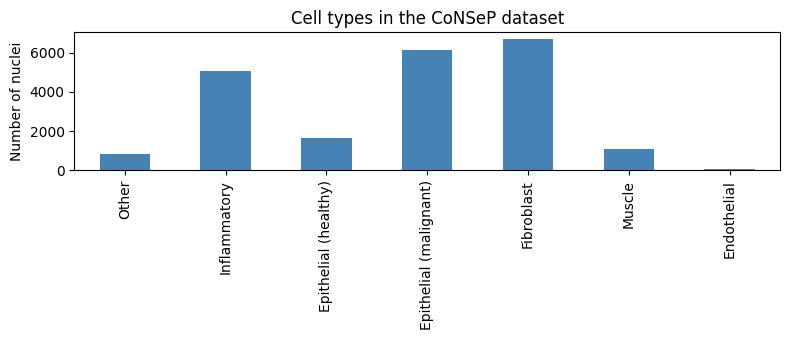

In [ ]:
counts = df["cell_type"].value_counts().sort_index()
counts.index = [CELL_TYPE_NAMES[i] for i in counts.index]
print(counts)

counts.plot(kind="bar", color="steelblue", figsize=(8, 3.5))
plt.ylabel("Number of nuclei")
plt.title("Cell types in the CoNSeP dataset")
plt.tight_layout()
plt.show()

## Step 6 — Create the positive vs. negative label

Just like in HIMLT, we turn this into a **binary** question.
Following our paper, types 3 and 4 together form the **Epithelial** group:

- **Positive (1):** epithelial nuclei (types 3 and 4)
- **Negative (0):** everything else (inflammatory, fibroblast, muscle, ...)

In [ ]:
df["label"] = df["cell_type"].isin([3, 4]).astype(int)

print(df["label"].value_counts().rename({1: "Positive (Epithelial)", 0: "Negative (Others)"}))
print(f"\n{df['label'].mean():.1%} of the nuclei are positive.")

label
Negative (Others)        13705
Positive (Epithelial)     7773
Name: count, dtype: int64

36.2% of the nuclei are positive.


## Step 7 — Split into modalities, and into train / test

Two things happen here:

1. We separate the columns into the **hand-crafted matrix `H`** (24 columns) and the
   **deep matrix `D`** (128 columns). Metadata columns (image name, position, ...) are dropped —
   the classifier should only see image-derived measurements.
2. We split into **train** and **test** sets using the `dataset_split` column.
   This split is **by image** (27 training images, 14 test images), the same split used in the paper.

> **Why not split randomly?** Nuclei from the same image look alike (same staining, same patient).
> If nuclei from one image ended up in both train and test, the model could "cheat" by
> memorizing the image style instead of learning real biology. This mistake is called
> **data leakage** — splitting by image prevents it.

We also **standardize** each feature (subtract mean, divide by standard deviation).
Important detail: the mean/std are computed **on the training set only**, then applied to the
test set — computing them on all data would be another subtle form of leakage.

In [ ]:
HAND_COLS = ['rb_ratio', 'r_median', 'r_mean', 'b_dominance', 'r_dominance',
             'intensity_median', 'intensity_mean', 'b_median', 'b_mean', 'r_min',
             'g_median', 'g_mean', 'gb_ratio', 'intensity_min', 'g_min',
             'perimeter', 'equivalent_diameter', 'feret_diameter_max', 'g_dominance',
             'major_axis_length', 'area', 'b_min', 'minor_axis_length', 'elongation']
DEEP_COLS = [f"pca_{i}" for i in range(128)]

# A few cells have missing values; fill them with the training-set median
train_mask = df["dataset_split"] == "train"
medians = df.loc[train_mask, HAND_COLS + DEEP_COLS].median()
df[HAND_COLS + DEEP_COLS] = df[HAND_COLS + DEEP_COLS].fillna(medians)

train_df = df[train_mask]
test_df  = df[~train_mask]

y_train = train_df["label"].values
y_test  = test_df["label"].values

# Standardize each modality (fit on train only!)
hand_scaler = StandardScaler().fit(train_df[HAND_COLS])
deep_scaler = StandardScaler().fit(train_df[DEEP_COLS])

H_train = hand_scaler.transform(train_df[HAND_COLS])
H_test  = hand_scaler.transform(test_df[HAND_COLS])
D_train = deep_scaler.transform(train_df[DEEP_COLS])
D_test  = deep_scaler.transform(test_df[DEEP_COLS])

print(f"Train: {H_train.shape[0]:,} nuclei   |  Test: {H_test.shape[0]:,} nuclei")
print(f"Hand-crafted matrix H: {H_train.shape[1]} features")
print(f"Deep matrix D:         {D_train.shape[1]} features")

Train: 15,555 nuclei   |  Test: 5,923 nuclei
Hand-crafted matrix H: 24 features
Deep matrix D:         128 features


## Step 8 — Baselines: how good is each modality on its own?

Before fusing anything, we need reference points. We train the same classifier
(**XGBoost**, the best model in our paper) three times:

- **A.** on hand-crafted features only
- **B.** on deep features only
- **C.** on both, simply glued side by side (concatenation)

The helper function below trains a model and reports five standard metrics.
`scale_pos_weight` tells XGBoost that the classes are imbalanced
(there are fewer positives than negatives).

In [ ]:
def train_and_evaluate(X_train, X_test, name):
    """Train an XGBoost classifier and return a dict of test-set metrics."""
    # Ratio of negatives to positives, so the model pays fair attention to the smaller class
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    model = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=pos_weight,
        eval_metric="logloss", random_state=42, n_jobs=-1,
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Approach":  name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall":    recall_score(y_test, pred),
        "F1":        f1_score(y_test, pred),
        "ROC-AUC":   roc_auc_score(y_test, prob),
    }
    print(f"{name:28s}  Accuracy={metrics['Accuracy']:.4f}  F1={metrics['F1']:.4f}  ROC-AUC={metrics['ROC-AUC']:.4f}")
    PREDICTIONS[name] = {"pred": pred, "prob": prob, "model": model}
    return metrics

results = []
PREDICTIONS = {}

In [ ]:
# Baseline A — hand-crafted features only (24 features)
results.append(train_and_evaluate(H_train, H_test, "A. Hand-crafted only"))

A. Hand-crafted only          Accuracy=0.8053  F1=0.7343  ROC-AUC=0.8801


In [ ]:
# Baseline B — deep features only (128 features)
results.append(train_and_evaluate(D_train, D_test, "B. Deep only"))

B. Deep only                  Accuracy=0.8533  F1=0.8002  ROC-AUC=0.9169


In [ ]:
# Baseline C — simple concatenation (24 + 128 = 152 features side by side)
C_train = np.hstack([H_train, D_train])
C_test  = np.hstack([H_test,  D_test])
results.append(train_and_evaluate(C_train, C_test, "C. Concatenation"))

C. Concatenation              Accuracy=0.8521  F1=0.7982  ROC-AUC=0.9189


## Step 9 — HMAF: Hybrid Modality Attention-based Fusion

Concatenation treats every feature equally. HMAF instead **weights the two modalities
per nucleus**: for one cell the shape measurements might matter more, for another the deep
features might. Here is the recipe (equation numbers match the paper):

1. **Project both modalities to a common size** *p* (Eq. 1–2):
   `H_proj = W_H · H + b_H` and `D_proj = W_D · D + b_D` — two linear layers.
2. **Score each modality** with its own tiny MLP (Eq. 3–4):
   `α = sigmoid(MLP_H(H_proj))`, `β = sigmoid(MLP_D(D_proj))` — one number per nucleus per modality.
3. **Normalize** the two scores with softmax so they compete: `[w_H, w_D] = softmax([α, β])` (Eq. 5).
   Now `w_H + w_D = 1` for every nucleus.
4. **Fuse** with a weighted sum (Eq. 6): `F = w_H · H_proj + w_D · D_proj`.
5. **Keep the originals too** (Eq. 7): the final feature vector is `[F, H, D]` —
   the fused representation plus both raw modalities.

The class below is the exact module from our published code — read it line by line
and match each part to the five steps above.

In [ ]:
class ModalityAttentionFusion(nn.Module):
    """HMAF fusion block (Eq. 1-7 of the paper)."""

    def __init__(self, hand_dim=24, deep_dim=128, proj_dim=128, hidden_dim=64):
        super().__init__()
        # (1) projection layers to a common dimension (Eq. 1-2)
        self.hand_proj = nn.Linear(hand_dim, proj_dim)
        self.deep_proj = nn.Linear(deep_dim, proj_dim)
        # (2) modality-specific attention MLPs (Eq. 3-4)
        self.hand_mlp = nn.Sequential(
            nn.Linear(proj_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        self.deep_mlp = nn.Sequential(
            nn.Linear(proj_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))

    def forward(self, hand_features, deep_features):
        # (1) project (Eq. 1-2)
        hand_proj = self.hand_proj(hand_features)   # (batch, proj_dim)
        deep_proj = self.deep_proj(deep_features)   # (batch, proj_dim)

        # (2) one attention score per modality (Eq. 3-4)
        alpha = torch.sigmoid(self.hand_mlp(hand_proj))   # weight for hand-crafted
        beta  = torch.sigmoid(self.deep_mlp(deep_proj))   # weight for deep

        # (3) softmax so the two weights sum to 1 (Eq. 5)
        weights = F.softmax(torch.cat([alpha, beta], dim=1), dim=1)
        w_hand, w_deep = weights[:, 0:1], weights[:, 1:2]

        # (4) weighted fusion (Eq. 6)
        fused = w_hand * hand_proj + w_deep * deep_proj

        # (5) concatenate fused + original features (Eq. 7)
        final_features = torch.cat([fused, hand_features, deep_features], dim=1)
        return final_features, w_hand, w_deep


# fix the seed here too, so this cell gives the same result no matter what ran before it
torch.manual_seed(42)

fusion_model = ModalityAttentionFusion(hand_dim=len(HAND_COLS), deep_dim=len(DEEP_COLS))
fusion_model.eval()   # we only run the module forward, exactly as in the published pipeline

with torch.no_grad():
    F_train, w_hand_train, _ = fusion_model(torch.tensor(H_train, dtype=torch.float32),
                                            torch.tensor(D_train, dtype=torch.float32))
    F_test,  w_hand_test,  _ = fusion_model(torch.tensor(H_test,  dtype=torch.float32),
                                            torch.tensor(D_test,  dtype=torch.float32))

F_train = F_train.numpy()
F_test  = F_test.numpy()

print(f"HMAF output: {F_train.shape[1]} features per nucleus "
      f"(128 fused + {len(HAND_COLS)} hand-crafted + {len(DEEP_COLS)} deep)")

HMAF output: 280 features per nucleus (128 fused + 24 hand-crafted + 128 deep)


In [ ]:
# Approach D — classify with the HMAF-fused features
results.append(train_and_evaluate(F_train, F_test, "D. HMAF fusion (ours)"))

D. HMAF fusion (ours)         Accuracy=0.8585  F1=0.8063  ROC-AUC=0.9237


## Step 10 — Compare all four approaches

Let's put everything side by side and save the table and chart to the `results/` folder.

,Accuracy,Precision,Recall,F1,ROC-AUC
Approach,,,,,
A. Hand-crafted only,0.8053,0.7575,0.7124,0.7343,0.8801
B. Deep only,0.8533,0.8235,0.7782,0.8002,0.9169
C. Concatenation,0.8521,0.8229,0.7750,0.7982,0.9189
D. HMAF fusion (ours),0.8585,0.8344,0.7800,0.8063,0.9237


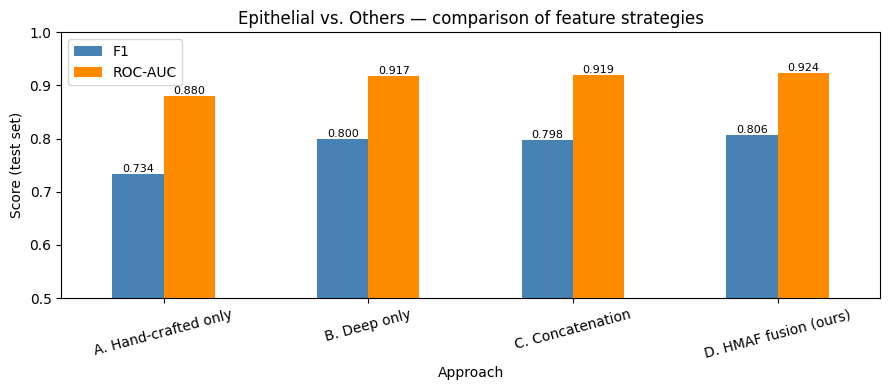

Saved: results/comparison_epithelial_vs_others.csv and .png


In [ ]:
results_df = pd.DataFrame(results).set_index("Approach")
display(results_df.round(4))

# Bar chart comparing F1 and ROC-AUC
ax = results_df[["F1", "ROC-AUC"]].plot(kind="bar", figsize=(9, 4),
                                        color=["steelblue", "darkorange"], rot=15)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score (test set)")
ax.set_title("Epithelial vs. Others — comparison of feature strategies")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.tight_layout()

import os
os.makedirs("results", exist_ok=True)
plt.savefig("results/comparison_epithelial_vs_others.png", dpi=150)
results_df.round(4).to_csv("results/comparison_epithelial_vs_others.csv")
plt.show()
print("Saved: results/comparison_epithelial_vs_others.csv and .png")

## Step 11 — Look inside HMAF: the attention weights

One advantage of HMAF over plain concatenation is that we can **inspect** it:
for every nucleus we get `w_hand` (and `w_deep = 1 − w_hand`) — how much the fusion
leaned on each modality for that particular cell.

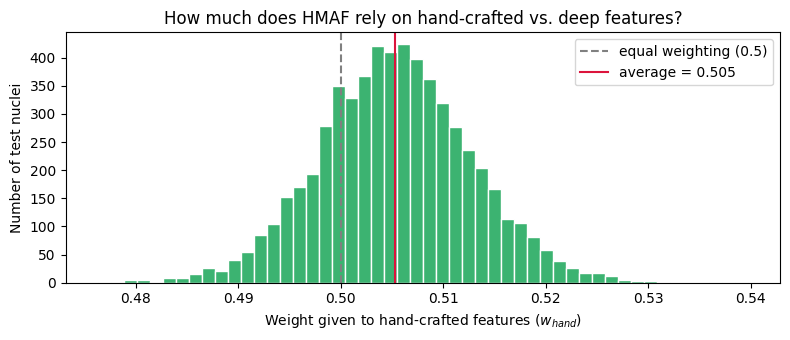

On average, HMAF gives 50.5% of the weight to hand-crafted features and 49.5% to deep features.


In [ ]:
w = w_hand_test.numpy().ravel()

plt.figure(figsize=(8, 3.5))
plt.hist(w, bins=50, color="mediumseagreen", edgecolor="white")
plt.axvline(0.5, color="gray", linestyle="--", label="equal weighting (0.5)")
plt.axvline(w.mean(), color="crimson", linestyle="-",
            label=f"average = {w.mean():.3f}")
plt.xlabel("Weight given to hand-crafted features ($w_{hand}$)")
plt.ylabel("Number of test nuclei")
plt.title("How much does HMAF rely on hand-crafted vs. deep features?")
plt.legend()
plt.tight_layout()
plt.savefig("results/attention_weights_histogram.png", dpi=150)
plt.show()

print(f"On average, HMAF gives {w.mean():.1%} of the weight to hand-crafted features "
      f"and {1 - w.mean():.1%} to deep features.")

## Step 12 — See the predictions on real nuclei

Accuracy and F1 are useful, but they are just numbers. In this step we look at the
**actual cells** the model was judging, and put its **prediction next to the truth**.

We use **`test_12`**, one of the held-out test images. The model never saw this image while
training, so everything below is a genuine prediction — not something it memorised.

### 12a — The confusion matrix

The clearest summary of a binary classifier: how many of each class it got right, and
*how* it got the rest wrong.

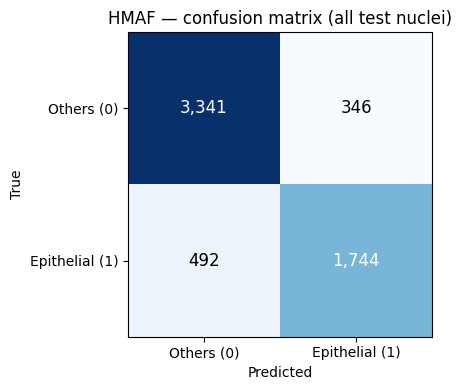

Correctly found epithelial nuclei (true positives): 1,744
Missed epithelial nuclei        (false negatives): 492
Others wrongly called epithelial (false positives): 346
Correctly rejected others        (true negatives): 3,341


In [ ]:
from sklearn.metrics import confusion_matrix
from PIL import Image

pred = PREDICTIONS["D. HMAF fusion (ours)"]["pred"]
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(cm, cmap="Blues")
names = ["Others (0)", "Epithelial (1)"]
ax.set_xticks([0, 1], names); ax.set_yticks([0, 1], names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("HMAF — confusion matrix (all test nuclei)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Correctly found epithelial nuclei (true positives): {tp:,}")
print(f"Missed epithelial nuclei        (false negatives): {fn:,}")
print(f"Others wrongly called epithelial (false positives): {fp:,}")
print(f"Correctly rejected others        (true negatives): {tn:,}")

### 12b — Look at the actual nuclei

Below are real nucleus images cropped from `test_12`. Each one is captioned with what the
model **predicted** and what it **truly is** — green when the model was right, red when wrong.

Pay attention to the bottom row. Those are the model's mistakes, and you will usually see
*why* it slipped: the confusing nuclei genuinely look like the other class.

428 nuclei in test_12 | model got 83.6% of them right


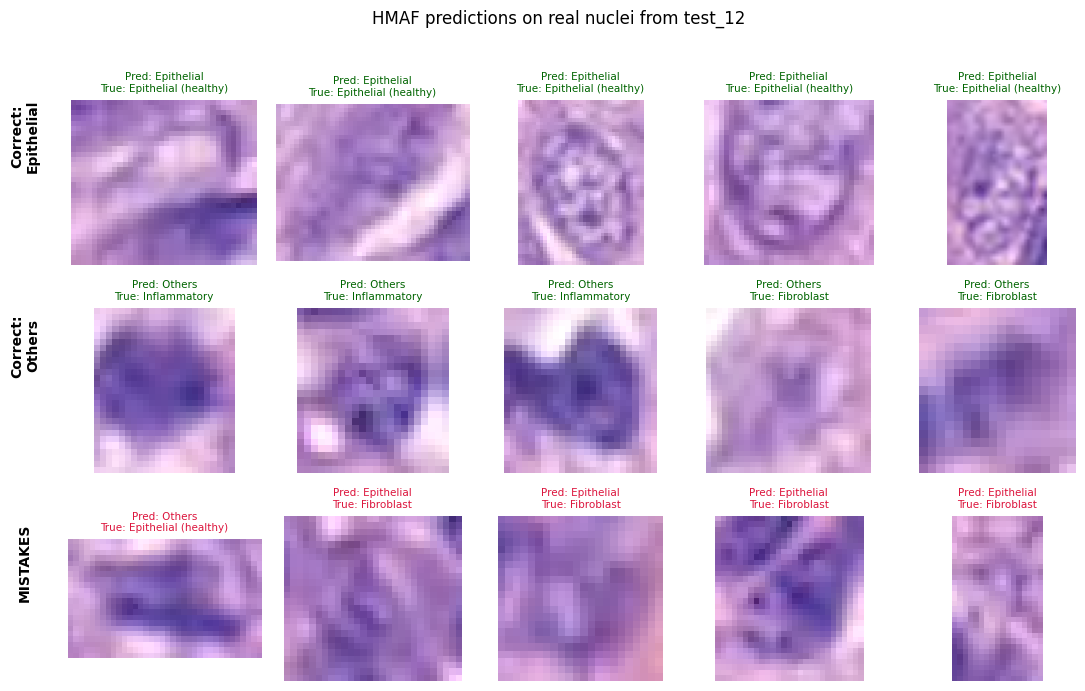

In [ ]:
img12 = np.array(Image.open("/content/drive/MyDrive/sample_data/test_12.png").convert("RGB"))

ev = test_df.copy()
ev["pred"] = pred
sel = ev[ev["image_name"] == "test_12"]
print(f"{len(sel)} nuclei in test_12 | model got {(sel.pred == sel.label).mean():.1%} of them right")

def crop_nucleus(row):
    return img12[int(row.bbox_y0):int(row.bbox_y1), int(row.bbox_x0):int(row.bbox_x1)]

groups = [
    ("Correct:\nEpithelial", sel[(sel.label == 1) & (sel.pred == 1)]),
    ("Correct:\nOthers",     sel[(sel.label == 0) & (sel.pred == 0)]),
    ("MISTAKES",              sel[sel.label != sel.pred]),
]

N = 5
fig, axes = plt.subplots(3, N, figsize=(11, 7))
for r, (title, g) in enumerate(groups):
    picks = g.sample(min(N, len(g)), random_state=0)
    for c in range(N):
        ax = axes[r, c]; ax.axis("off")
        if c < len(picks):
            row = picks.iloc[c]
            ax.imshow(crop_nucleus(row))
            p_name = "Epithelial" if row.pred == 1 else "Others"
            t_name = CELL_TYPE_NAMES[row.cell_type]
            correct = row.pred == row.label
            ax.set_title(f"Pred: {p_name}\nTrue: {t_name}", fontsize=7.5,
                         color="darkgreen" if correct else "crimson")
for r, y in zip(range(3), [0.80, 0.50, 0.19]):
    fig.text(0.015, y, groups[r][0], fontsize=10, weight="bold", rotation=90,
             va="center", ha="center")
plt.suptitle("HMAF predictions on real nuclei from test_12", fontsize=12)
plt.tight_layout(rect=[0.04, 0, 1, 0.96])
plt.savefig("results/prediction_examples.png", dpi=150, bbox_inches="tight")
plt.show()

### 12c — The whole image: prediction vs. truth

Finally, the same view **HIMLT shows a pathologist**: every nucleus marked on the tissue,
**magenta = positive (epithelial)** and **cyan = negative (others)**.

The left panel is what the model predicted; the right panel is the ground truth.
Anywhere the colours differ is a mistake — see if you can spot the regions where the model
struggles.

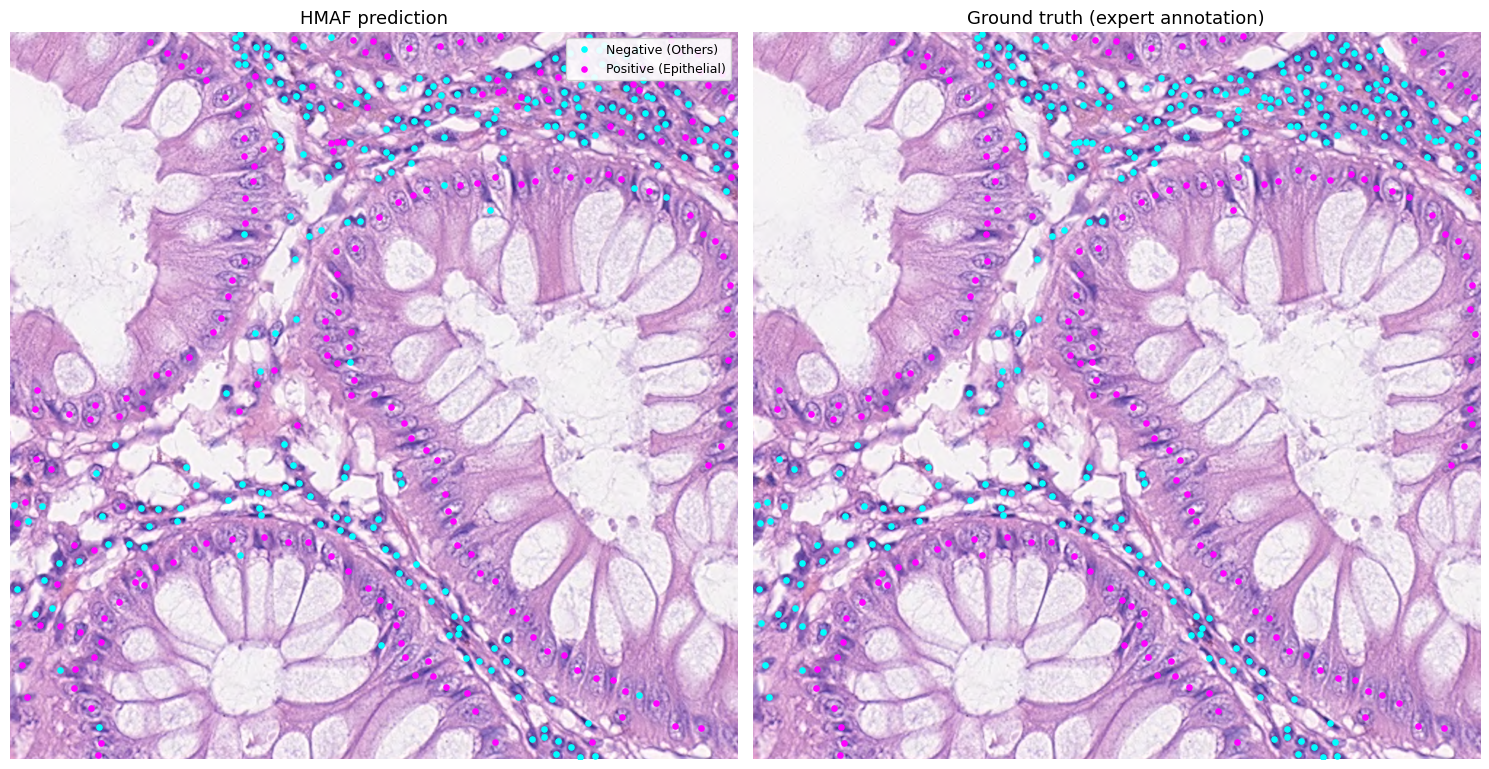

65 of 428 nuclei are coloured differently between the two panels.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.6))
for ax, col, title in [(axes[0], "pred", "HMAF prediction"),
                       (axes[1], "label", "Ground truth (expert annotation)")]:
    ax.imshow(img12); ax.axis("off"); ax.set_title(title, fontsize=13)
    neg, pos = sel[sel[col] == 0], sel[sel[col] == 1]
    ax.scatter(neg.centroid_x, neg.centroid_y, s=14, c="cyan",    label="Negative (Others)")
    ax.scatter(pos.centroid_x, pos.centroid_y, s=14, c="magenta", label="Positive (Epithelial)")
axes[0].legend(loc="upper right", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig("results/prediction_overlay_test_12.png", dpi=120, bbox_inches="tight")
plt.show()

wrong = sel[sel.pred != sel.label]
print(f"{len(wrong)} of {len(sel)} nuclei are coloured differently between the two panels.")

## Take-home exercises

Try these during the week — each one is a small edit to a single cell.
Bring your results (numbers or plots) to the next session!

1. **Change the positive class.** In Step 6, replace `isin([3, 4])` to make
   *Inflammatory vs. Others* (`isin([2])`) or *Spindle vs. Others* (`isin([5, 6, 7])`).
   Which task is easiest? Does HMAF help more, or less?
2. **Try a different classifier.** In Step 8's `train_and_evaluate`, swap `XGBClassifier` for
   `RandomForestClassifier(n_estimators=300, random_state=42)` or
   `LogisticRegression(max_iter=2000)` (both from scikit-learn — remember to import them,
   and note that these models don't use `scale_pos_weight`; use `class_weight="balanced"` instead).
   Does XGBoost stay in front, as it did in the paper?
3. **Change the projection size.** In Step 9, try `proj_dim=64` or `proj_dim=256`.
   How does the final feature count and the score change?
4. **(Challenge) Train the attention.** In our published pipeline the fusion block is applied
   as a fixed transformation. Add a small classification head
   (`nn.Linear(final_dim, 1)`), train it end-to-end for a few epochs with
   `nn.BCEWithLogitsLoss()` and `torch.optim.Adam`, then re-extract the fused features.
   Do the learned attention weights move away from 0.5? Does the classifier improve?

### Recap

- Hand-crafted and deep features carry **complementary** information.
- Combining them helps, and **attention-based fusion (HMAF)** combines them adaptively,
  per nucleus, while staying interpretable via the attention weights.
- Careful methodology matters: split **by image**, standardize using **train statistics only**.
